<a href="https://colab.research.google.com/github/namann010/Credit-Card-Fraud-Detectrion/blob/main/credit_card_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec

In [4]:
data= pd.read_csv("creditcard.csv")
print(data.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [5]:
print(data.describe())

                Time             V1             V2             V3  \
count  192217.000000  192217.000000  192217.000000  192217.000000   
mean    68184.073844      -0.119304       0.008753       0.359554   
std     33047.933474       1.886963       1.621254       1.436355   
min         0.000000     -56.407510     -72.715728     -33.680984   
25%     43474.000000      -0.967140      -0.574871      -0.270972   
50%     65611.000000      -0.108100       0.085438       0.523250   
75%     85905.000000       1.205997       0.785142       1.241678   
max    129594.000000       2.439207      22.057729       9.382558   

                  V4             V5             V6             V7  \
count  192216.000000  192216.000000  192216.000000  192216.000000   
mean        0.084969      -0.127450       0.049838      -0.058504   
std         1.394042       1.357811       1.307049       1.214081   
min        -5.683171     -42.147898     -26.160506     -43.557242   
25%        -0.782560      -0.7951

In [6]:
fraud= data[data['Class']==1]
valid= data[data['Class']==0]
outlier_fraction= len(fraud)/float(len(valid))
print(outlier_fraction)
print('fraud cases:{}'.format(len(data[data['Class']==1])))
print('valid Transactions:{}' .format(len(data[data['Class']==0])))

0.0019651895599956215
fraud cases:377
valid Transactions:191839


In [9]:
print('Amount details of the fraudulent transaction')
fraud.Amount.describe()

Amount details of the fraudulent transaction


,Amount
count,377.000000
mean,115.954218
std,247.741483
min,0.000000
25%,1.000000
50%,11.400000
75%,104.000000
max,2125.870000


In [10]:
print('Amount detail of valid transactions')
valid.Amount.describe()

Amount detail of valid transactions


,Amount
count,191839.000000
mean,89.345488
std,248.537176
min,0.000000
25%,5.990000
50%,22.890000
75%,79.000000
max,19656.530000


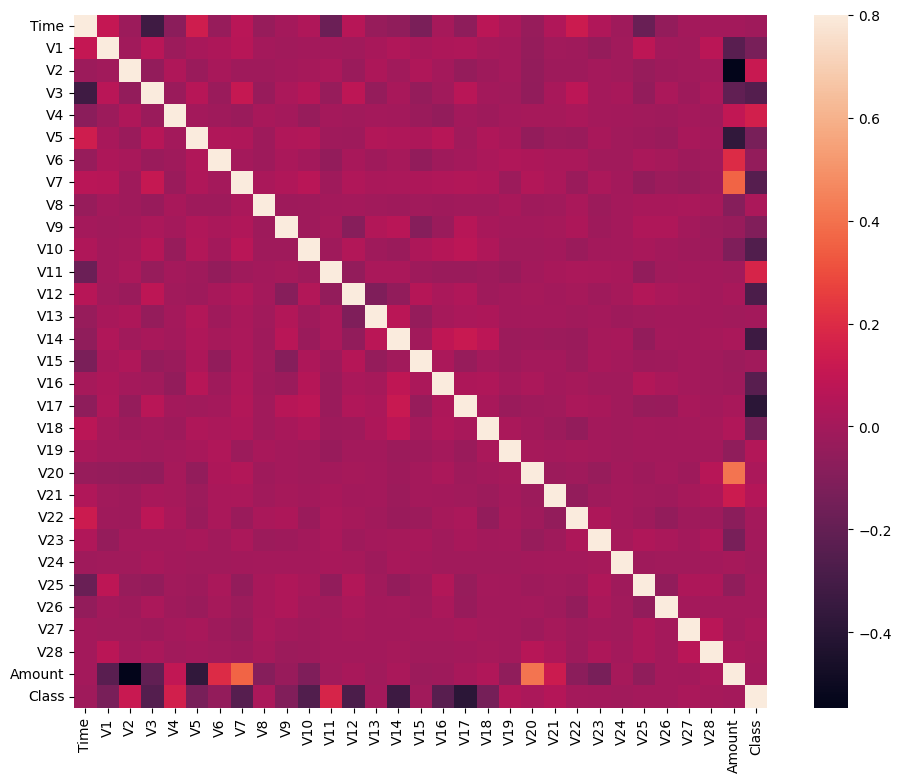

In [11]:
corrmat = data.corr()
fig= plt.figure(figsize=(12,9))
sns.heatmap(corrmat,vmax=0.8,square=True)
plt.show()

In [23]:
# Drop rows where 'Class' is NaN before splitting
data_cleaned = data.dropna(subset=['Class'])
x = data_cleaned.drop(['Class'], axis=1)
y = data_cleaned['Class']

print(x.shape)
print(y.shape)

xData = x.values
yData = y.values

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(xData, yData, test_size=0.2, random_state=42)

(192216, 30)
(192216,)


In [24]:
from sklearn.ensemble import RandomForestClassifier
rfc= RandomForestClassifier()
rfc.fit(x_train,y_train)

y_pred=rfc.predict(x_test)

Model Evaluation Metrics:
accuracy:0.9998
Precision: 0.9608
Recall: 0.8909
F1-Score: 0.9245
Matthews Correlation Coefficient: 0.9251


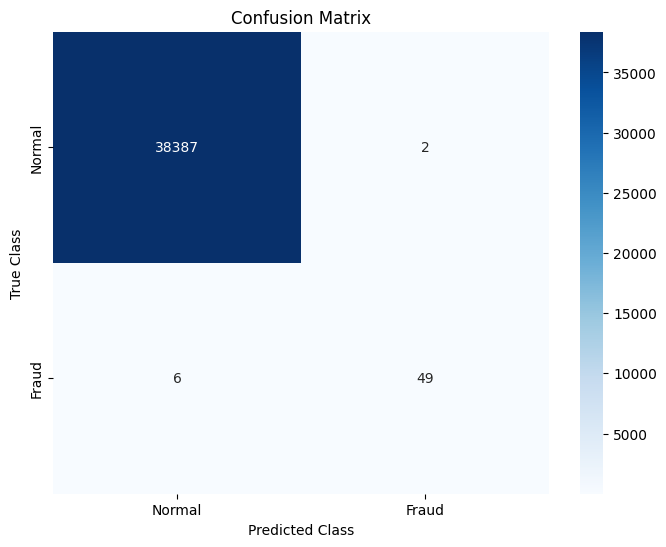

In [31]:
from sklearn.metrics import accuracy_score,confusion_matrix,recall_score,precision_score,f1_score,matthews_corrcoef
accuracy=accuracy_score(y_test, y_pred)
recall=recall_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
mcc=matthews_corrcoef(y_test,y_pred)

print("Model Evaluation Metrics:")
print(f"accuracy:{accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Matthews Correlation Coefficient: {mcc:.4f}")

conf_matrix = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()